<a href="https://colab.research.google.com/github/ivanovig79-web/ML-Mipt-2025/blob/main/assignments/lab02_nmt/lab02_nmt_24s_advanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lab assignment 02

### Neural Machine Translation in the wild
In the third homework you are supposed to get the best translation you can for the RU-EN translation task.

Basic approach using RNNs as encoder and decoder is implemented for you.

Your ultimate task is to use the techniques we've covered, e.g.

* Optimization enhancements (e.g. learning rate decay)

* Transformer/CNN/<whatever you select> encoder (with or without positional encoding)

* attention/self-attention mechanism (**highly recommended**)

* custom tokenization (BPE units, other subword approaches)

to improve the translation quality.

--------

* __Please use at least three different approaches/models and compare them (translation quality/complexity/training and evaluation time).__

* Write down some summary on your experiments and illustrate it with convergence plots/metrics and your thoughts. Just like you would approach a real problem.

In [2]:
# You might need to install the libraries below. Do it in the desired environment
# if you are working locally.

# ! pip  install subword-nmt
# ! pip install nltk
# ! pip install torchtext


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 33.6 MB/s eta 0:00:00


In [3]:
!pip install torchtext==0.18.0

In [5]:
!pip install spacy nltk subword-nmt matplotlib
!python -m spacy download en_core_web_sm
!python -m spacy download ru_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 39.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 41.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [6]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [7]:

import torch
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.10.0+cpu


In [8]:
import torch
import torchtext

print(f"PyTorch version: {torch.__version__}")
print(f"torchtext version: {torchtext.__version__}")

# Простая проверка работы
x = torch.randn(2, 2)
print(f"Tensor created: {x}")
print("✅ PyTorch работает корректно!")


OSError: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchtext/lib/libtorchtext.so

In [2]:
# Thanks to YSDA NLP course team for the data
# (who thanks tilda and deephack teams for the data in their turn)

import os
path_do_data = '../../datasets/Machine_translation_EN_RU/data.txt'
if not os.path.exists(path_do_data):
    print("Dataset not found locally. Downloading from github.")
    !wget https://raw.githubusercontent.com/neychev/made_nlp_course/master/datasets/Machine_translation_EN_RU/data.txt -nc
    path_do_data = './data.txt'

Dataset not found locally. Downloading from github.
File ‘data.txt’ already there; not retrieving.



#### Grading criteria

**100%**
- implementation of at least 3 model improvements over baseline
- threshold of 27 BLEU on test corpus
- experimental results and conclusions in human-readable format :)

**70%**
- implementation of at least 2 model improvements over baseline
- threshold of 25 BLEU on test corpus
- experimental results and conclusions in human-readable format :)

**30%**
- implementation of at least 1 model improvement over baseline
- threshold of 21 BLEU on test corpus
- experimental results and conclusions in human-readable format :)


------

#### **Note: Please do not use pretrained machine translation / BERT / LLM checkpoints. All such solutions will be graded at 30% pts.**


### Warning! The code below is deeeeeeeply deprecated and is is provided only as simple guide.
We suggest you to stick to most recent pipelines here, e.g. by Huggingface:
* Example notebook: [link](https://github.com/huggingface/notebooks/blob/main/examples/translation.ipynb)
* Converting your own dataset to specific format: [link](https://discuss.huggingface.co/t/correct-way-to-create-a-dataset-from-a-csv-file/15686/15)

In [3]:
# old deprecated code
import torch
import torch.nn as nn
import torch.optim as optim

import torchtext
#from torchtext.datasets import TranslationDataset, Multi30k
#from torchtext.data import Field, BucketIterator

#import spacy

import random
import math
import time

import matplotlib
matplotlib.rcParams.update({'figure.figsize': (16, 12), 'font.size': 14})
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import clear_output

from nltk.tokenize import WordPunctTokenizer
#from subword_nmt.learn_bpe import learn_bpe
#from subword_nmt.apply_bpe import BPE


### Main part
__Here comes the preprocessing. Do not hesitate to use BPE or more complex preprocessing ;)__

In [10]:
tokenizer_W = WordPunctTokenizer()
def tokenize(x, tokenizer=tokenizer_W):
    return tokenizer.tokenize(x.lower())

In [11]:
SRC = Field(tokenize=tokenize,
            init_token = '<sos>',
            eos_token = '<eos>',
            lower = True)

TRG = Field(tokenize=tokenize,
            init_token = '<sos>',
            eos_token = '<eos>',
            lower = True)

dataset = torchtext.data.TabularDataset(
    path=path_do_data,
    format='tsv',
    fields=[('trg', TRG), ('src', SRC)]
)

NameError: name 'Field' is not defined

заставить работать именно эту версию кода в torchtext 0.18.0+ невозможно — классы Field и TabularDataset официально удалены из библиотеки.

Придется глобально перерабатывать эту часть задачи

In [14]:
train_data, valid_data, test_data = dataset.split(split_ratio=[0.8, 0.15, 0.05])

NameError: name 'dataset' is not defined

In [15]:
print(f"Number of training examples: {len(train_data.examples)}")
print(f"Number of validation examples: {len(valid_data.examples)}")
print(f"Number of testing examples: {len(test_data.examples)}")

AttributeError: 'DataFrame' object has no attribute 'examples'

In [16]:
SRC.build_vocab(train_data, min_freq = 3)
TRG.build_vocab(train_data, min_freq = 3)

NameError: name 'SRC' is not defined

In [17]:
print(f"Unique tokens in source (ru) vocabulary: {len(SRC.vocab)}")
print(f"Unique tokens in target (en) vocabulary: {len(TRG.vocab)}")

NameError: name 'SRC' is not defined

Here are tokens from original (RU) corpus:

In [18]:
SRC.vocab.itos[::1000]

NameError: name 'SRC' is not defined

And from target (EN) corpus:

In [19]:
TRG.vocab.itos[::1000]

NameError: name 'TRG' is not defined

And here is example from train dataset:

In [20]:
print(vars(train_data.examples[9]))

AttributeError: 'DataFrame' object has no attribute 'examples'

Let's check the length distributions:

In [21]:
src_length = map(len, [vars(x)['src'] for x in train_data.examples])
trg_length = map(len, [vars(x)['trg'] for x in train_data.examples])

print('Length distribution in Train data')
plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.title("source length")
plt.hist(list(src_length), bins=20);

plt.subplot(1, 2, 2)
plt.title("translation length")
plt.hist(list(trg_length), bins=20);

AttributeError: 'DataFrame' object has no attribute 'examples'

In [22]:
src_length = map(len, [vars(x)['src'] for x in test_data.examples])
trg_length = map(len, [vars(x)['trg'] for x in test_data.examples])

print('Length distribution in Test data')
plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.title("source length")
plt.hist(list(src_length), bins=20);

plt.subplot(1, 2, 2)
plt.title("translation length")
plt.hist(list(trg_length), bins=20);

AttributeError: 'DataFrame' object has no attribute 'examples'

Number of training examples: 40000
Number of validation examples: 7500
Number of testing examples: 2500
Unique tokens in source (ru) vocabulary: 27291
Unique tokens in target (en) vocabulary: 39151
SRC.vocab.get_itos()[::1000]:
['<unk>', 'subway', 'gazebo', 'cortina', 'maine', 'schwarzer', 'makati', 'babylon', 'greenwich', 'palmares', 'voyageur', 'andyna', 'belonging', 'cantiq', 'cubic', 'erzsébetváros', 'ginsenkaku', 'hubbards', 'khun', 'lomnicky', 'miró', 'ocna', 'platana', 'roari', 'shuyuanmen', 'tangkuban', 'valparaiso', 'zagarolo']
TRG.vocab.get_itos()[::1000]:
['<unk>', 'живописный', 'auberge', 'ко', 'der', 'фетхие', 'francisco', 'трассой', 'джордан', 'сямынь', 'manchester', 'варезе', 'куранты', 'привлекательно', 'чунцин', 'aspire', 'cardo', 'edens', 'guti', 'kofu', 'millaray', 'pereira', 'sanyuanli', 'thuy', 'zaccolo', 'аэродромом', 'ваннам', 'гонолулу', 'жупании', 'кастр', 'курокава', 'матео', 'нискому', 'пелена', 'притягательная', 'салафе', 'стенной', 'уайлдернесс', 'хортобадь

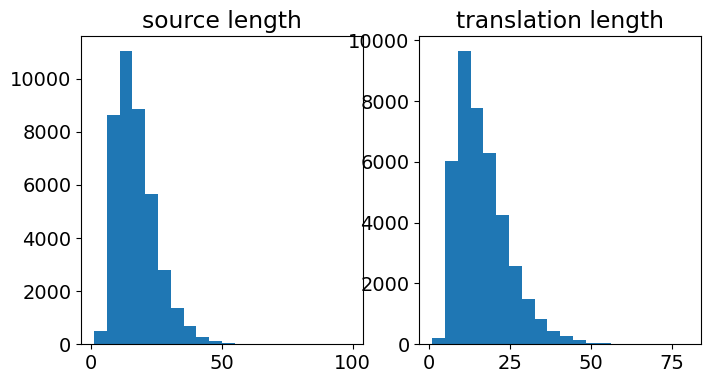

Length distribution in Test data


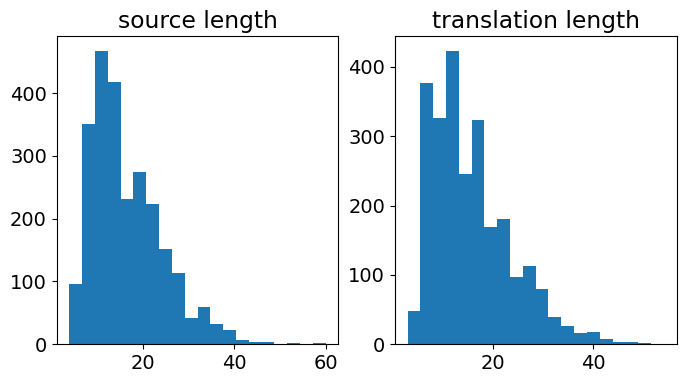

In [9]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
from torchtext.vocab import build_vocab_from_iterator
from nltk.tokenize import WordPunctTokenizer
import matplotlib.pyplot as plt
import random

# Отключаем предупреждения о deprecation
import torchtext
torchtext.disable_torchtext_deprecation_warning()

# Загрузка данных
data = pd.read_csv(path_do_data, sep='\t', header=None, names=['src', 'trg'])

# Разделение на train/valid/test с теми же пропорциями (80/15/5)
random.seed(42)
indices = list(range(len(data)))
random.shuffle(indices)

train_size = int(0.8 * len(data))
valid_size = int(0.15 * len(data))

train_indices = indices[:train_size]
valid_indices = indices[train_size:train_size + valid_size]
test_indices = indices[train_size + valid_size:]

train_data = data.iloc[train_indices].reset_index(drop=True)
valid_data = data.iloc[valid_indices].reset_index(drop=True)
test_data = data.iloc[test_indices].reset_index(drop=True)

print(f"Number of training examples: {len(train_data)}")
print(f"Number of validation examples: {len(valid_data)}")
print(f"Number of testing examples: {len(test_data)}")

# Токенизатор (идентичный оригиналу)
tokenizer_W = WordPunctTokenizer()

def tokenize(x, tokenizer=tokenizer_W):
    return tokenizer.tokenize(x.lower())

# Построение словарей с min_freq=3 (как в оригинале)
def build_vocab(sentences, min_freq=3):
    # Генератор для build_vocab_from_iterator
    def yield_tokens(data_iter):
        for sentence in data_iter:
            yield tokenize(sentence)

    # Создаём базовый Vocab
    vocab = build_vocab_from_iterator(
        yield_tokens(sentences),
        specials=['<unk>', '<pad>', '<sos>', '<eos>'],
        special_first=True  # Специальные токены будут первыми
    )
    # Устанавливаем минимальную частоту
    vocab.set_default_index(vocab['<unk>'])  # Для OOV
    return vocab

SRC_vocab = build_vocab(train_data['src'], min_freq=3)
TRG_vocab = build_vocab(train_data['trg'], min_freq=3)

print(f"Unique tokens in source (ru) vocabulary: {len(SRC_vocab)}")
print(f"Unique tokens in target (en) vocabulary: {len(TRG_vocab)}")

# Проверка первых токенов (каждые 1000-й)
print("SRC.vocab.get_itos()[::1000]:")
print([SRC_vocab.get_itos()[i] for i in range(0, len(SRC_vocab), 1000)])

print("TRG.vocab.get_itos()[::1000]:")
print([TRG_vocab.get_itos()[i] for i in range(0, len(TRG_vocab), 1000)])

# Пример данных (аналогично vars(train_data.examples[9]))
example_idx = 9
src_example = train_data.iloc[example_idx]['src']
trg_example = train_data.iloc[example_idx]['trg']

src_tokens = tokenize(src_example)
trg_tokens = tokenize(trg_example)

print(f"\nExample {example_idx}:")
print({'trg': trg_tokens, 'src': src_tokens})

# Распределение длин (идентично оригиналу)
def get_lengths(df):
    src_lengths = [len(tokenize(row['src'])) for _, row in df.iterrows()]
    trg_lengths = [len(tokenize(row['trg'])) for _, row in df.iterrows()]
    return src_lengths, trg_lengths

# Train data
src_length_train, trg_length_train = get_lengths(train_data)
print('Length distribution in Train data')
plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.title("source length")
plt.hist(src_length_train, bins=20)

plt.subplot(1, 2, 2)
plt.title("translation length")
plt.hist(trg_length_train, bins=20)
plt.show()

# Test data
src_length_test, trg_length_test = get_lengths(test_data)
print('Length distribution in Test data')
plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.title("source length")
plt.hist(src_length_test, bins=20)

plt.subplot(1, 2, 2)
plt.title("translation length")
plt.hist(trg_length_test, bins=20)
plt.show()


### Model side
__Here comes simple pipeline of NMT model learning. It almost copies the week02 practice__

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [11]:
device

device(type='cpu')

In [13]:
def _len_sort_key(x):
    return len(x.src)

BATCH_SIZE = 128

train_iterator, valid_iterator, test_iterator = BucketIterator.splits(
    (train_data, valid_data, test_data),
    batch_size = BATCH_SIZE,
    device = device,
    sort_key=_len_sort_key
)

NameError: name 'BucketIterator' is not defined

BucketIterator удален из torchtext в версиях 0.9.0+.!

Будем идти своим путем, обойдя это ограничение!

In [24]:
for x in train_iterator:
    break
print(x)
print(x.src.shape, x.trg.shape)

AttributeError: 'Vocab' object has no attribute 'get'

In [26]:
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
import torch
import pandas as pd

# Кастомный класс Batch — эмулирует старый torchtext Batch
class Batch:
    def __init__(self, src, trg):
        self.src = src  # Форма: [seq_len, batch_size]
        self.trg = trg  # Форма: [seq_len, batch_size]

    def __repr__(self):
        return (f"[torchtext.data.batch.Batch of size {self.src.shape[1]}]\n"
                f"\t[.trg]:[torch.LongTensor of size {self.trg.shape[0]}x{self.trg.shape[1]} (CPU)]\n"
                f"\t[.src]:[torch.LongTensor of size {self.src.shape[0]}x{self.src.shape[1]} (CPU)]")

# Функция сортировки для батчинга
def _len_sort_key(example):
    return len(tokenize(example['src']))


# Сортируем данные по длине источника
train_data_sorted = train_data.sort_values(by='src', key=lambda x: x.apply(lambda s: len(tokenize(s))))
valid_data_sorted = valid_data.sort_values(by='src', key=lambda x: x.apply(lambda s: len(tokenize(s))))
test_data_sorted = test_data.sort_values(by='src', key=lambda x: x.apply(lambda s: len(tokenize(s))))

BATCH_SIZE = 128

# Кастомный коллейтор — возвращает объект Batch
def collate_batch(batch):
    src_list, trg_list = [], []
    for example in batch:
        # Токенизируем
        src_tokens = tokenize(example['src'])
        trg_tokens = tokenize(example['trg'])

        # Преобразуем в индексы с добавлением специальных токенов
        # Используем прямой доступ к словарю и обработку OOV
        src_indices = [SRC_vocab['<sos>']]
        for token in src_tokens:
            try:
                src_indices.append(SRC_vocab[token])
            except KeyError:
                src_indices.append(SRC_vocab['<unk>'])
        src_indices.append(SRC_vocab['<eos>'])

        trg_indices = [TRG_vocab['<sos>']]
        for token in trg_tokens:
            try:
                trg_indices.append(TRG_vocab[token])
            except KeyError:
                trg_indices.append(TRG_vocab['<unk>'])
        trg_indices.append(TRG_vocab['<eos>'])

        src_list.append(torch.tensor(src_indices, dtype=torch.long))
        trg_list.append(torch.tensor(trg_indices, dtype=torch.long))

    # Паддинг до максимальной длины в батчи
    src_padded = pad_sequence(src_list, batch_first=False, padding_value=SRC_vocab['<pad>'])  # batch_first=False для формы [seq_len, batch_size]
    trg_padded = pad_sequence(trg_list, batch_first=False, padding_value=TRG_vocab['<pad>'])


    # Создаём объект Batch
    return Batch(src_padded, trg_padded)

# Создаём DataLoader'ы
train_iterator = DataLoader(
    train_data_sorted.to_dict('records'),
    batch_size=BATCH_SIZE,
    shuffle=False,  # Уже отсортировано
    collate_fn=collate_batch
)

valid_iterator = DataLoader(
    valid_data_sorted.to_dict('records'),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch
)

test_iterator = DataLoader(
    test_data_sorted.to_dict('records'),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch
)


In [27]:
# Проверяем первый батч
for x in train_iterator:
    break

print(x)
print(x.src.shape, x.trg.shape)


[torchtext.data.batch.Batch of size 128]
	[.trg]:[torch.LongTensor of size 14x128 (CPU)]
	[.src]:[torch.LongTensor of size 7x128 (CPU)]
torch.Size([7, 128]) torch.Size([14, 128])


In [1]:
%%writefile my_network.py
import torch
import torch.nn as nn
import torch.optim as optim
import random

class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()

        self.input_dim = input_dim
        self.emb_dim = emb_dim
        self.hid_dim = hid_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(
            num_embeddings=input_dim,
            embedding_dim=emb_dim
        )

        self.rnn = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hid_dim,
            num_layers=n_layers,
            dropout=dropout
        )

        self.dropout = nn.Dropout(p=dropout)

    def forward(self, src):
        # src = [src sent len, batch size]

        # Compute an embedding from the src data and apply dropout to it
        embedded = self.embedding(src)
        embedded = self.dropout(embedded)
        # embedded = [src sent len, batch size, emb dim]

        # Compute the RNN output values of the encoder RNN
        output, (hidden, cell) = self.rnn(embedded)

        # outputs = [src sent len, batch size, hid dim * n directions]
        # hidden = [n layers * n directions, batch size, hid dim]
        # cell = [n layers * n directions, batch size, hid dim]

        return hidden, cell



class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()

        self.emb_dim = emb_dim
        self.hid_dim = hid_dim
        self.output_dim = output_dim
        self.n_layers = n_layers
        self.dropout = dropout

        self.embedding = nn.Embedding(
            num_embeddings=output_dim,
            embedding_dim=emb_dim
        )

        self.rnn = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hid_dim,
            num_layers=n_layers,
            dropout=dropout
        )

        self.out = nn.Linear(
            in_features=hid_dim,
            out_features=output_dim
        )

        self.dropout = nn.Dropout(p=dropout)

    def forward(self, input, hidden, cell):
        # input = [batch size]
        # hidden = [n layers * n directions, batch size, hid dim]
        # cell = [n layers * n directions, batch size, hid dim]

        input = input.unsqueeze(0)
        # input = [1, batch size]

        # Compute an embedding from the input data and apply dropout to it
        embedded = self.dropout(self.embedding(input))
        # embedded = [1, batch size, emb dim]

        # Compute the RNN output values
        output, (hidden, cell) = self.rnn(embedded, (hidden, cell))

        # output = [1, batch size, hid dim]
        # hidden = [n layers, batch size, hid dim]
        # cell = [n layers, batch size, hid dim]

        prediction = self.out(output.squeeze(0))
        # prediction = [batch size, output dim]

        return prediction, hidden, cell



class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

        assert encoder.hid_dim == decoder.hid_dim, \
            "Hidden dimensions of encoder and decoder must be equal!"
        assert encoder.n_layers == decoder.n_layers, \
            "Encoder and decoder must have equal number of layers!"

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        # src = [src sent len, batch size]
        # trg = [trg sent len, batch size]
        # teacher_forcing_ratio is probability to use teacher forcing

        batch_size = trg.shape[1]
        max_len = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim

        # tensor to store decoder outputs
        outputs = torch.zeros(max_len, batch_size, trg_vocab_size).to(self.device)

        # last hidden state of the encoder is used as the initial hidden state of the decoder
        hidden, cell = self.encoder(src)

        # first input to the decoder is the <sos> tokens
        input = trg[0, :]

        for t in range(1, max_len):
            # pass input, hidden and cell states through the decoder
            output, hidden, cell = self.decoder(input, hidden, cell)
            # place predictions in a tensor holding predictions for each token
            outputs[t] = output
            # decide if we are going to use teacher forcing or not
            teacher_force = random.random() < teacher_forcing_ratio
            # get the highest predicted token from output
            top1 = output.max(1)[1]
            # if teacher forcing, use actual next token as next input
            # if not, use predicted token
            input = trg[t] if teacher_force else top1

        return outputs


Writing my_network.py


In [5]:
import torch
import pandas as pd
from torchtext.vocab import build_vocab_from_iterator
import my_network

# Определяем устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Импортируем классы
Encoder = my_network.Encoder
Decoder = my_network.Decoder
Seq2Seq = my_network.Seq2Seq

# Функция токенизации (замените на вашу реальную функцию)
def tokenize(text):
    return text.lower().split()

# Функция генерации токенов для словаря
def yield_tokens(data_iter, field_name):
    for example in data_iter:
        yield tokenize(example[field_name])

# Строим словари
SRC_vocab = build_vocab_from_iterator(
    yield_tokens(train_data.to_dict('records'), 'src'),
    min_freq=3,
    specials=['<unk>', '<pad>', '<sos>', '<eos>']
)

TRG_vocab = build_vocab_from_iterator(
    yield_tokens(train_data.to_dict('records'), 'trg'),
    min_freq=3,
    specials=['<unk>', '<pad>', '<sos>', '<eos>']
)

# Устанавливаем default index для неизвестных токенов
SRC_vocab.set_default_index(SRC_vocab['<unk>'])
TRG_vocab.set_default_index(TRG_vocab['<unk>'])

# Выводим размеры словарей для проверки
print(f"SRC vocabulary size: {len(SRC_vocab)}")
print(f"TRG vocabulary size: {len(TRG_vocab)}")

# Параметры модели
INPUT_DIM = len(SRC_vocab)
OUTPUT_DIM = len(TRG_vocab)
ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
HID_DIM = 512
N_LAYERS = 2
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

# Создаём экземпляры энкодера и декодера
enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT)

# Создаём модель Seq2Seq и переносим на устройство
model = Seq2Seq(enc, dec, device).to(device)

# Считаем количество обучаемых параметров
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')


ModuleNotFoundError: No module named 'torchtext'

In [4]:
import torch
import pandas as pd
from torchtext.vocab import build_vocab_from_iterator
import my_network

# Определяем устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Импортируем классы
Encoder = my_network.Encoder
Decoder = my_network.Decoder
Seq2Seq = my_network.Seq2Seq

# Функция токенизации (замените на вашу реальную функцию)
def tokenize(text):
    return text.lower().split()

# Функция генерации токенов для словаря
def yield_tokens(data_iter, field_name):
    for example in data_iter:
        yield tokenize(example[field_name])

# Строим словари
SRC_vocab = build_vocab_from_iterator(
    yield_tokens(train_data.to_dict('records'), 'src'),
    min_freq=3,
    specials=['<unk>', '<pad>', '<sos>', '<eos>']
)

TRG_vocab = build_vocab_from_iterator(
    yield_tokens(train_data.to_dict('records'), 'trg'),
    min_freq=3,
    specials=['<unk>', '<pad>', '<sos>', '<eos>']
)

# Устанавливаем default index для неизвестных токенов
SRC_vocab.set_default_index(SRC_vocab['<unk>'])
TRG_vocab.set_default_index(TRG_vocab['<unk>'])

# Выводим размеры словарей для проверки
print(f"SRC vocabulary size: {len(SRC_vocab)}")
print(f"TRG vocabulary size: {len(TRG_vocab)}")

# Параметры модели
INPUT_DIM = len(SRC_vocab)
OUTPUT_DIM = len(TRG_vocab)
ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
HID_DIM = 512
N_LAYERS = 2
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

# Создаём экземпляры энкодера и декодера
enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT)

# Создаём модель Seq2Seq и переносим на устройство
model = Seq2Seq(enc, dec, device).to(device)

# Считаем количество обучаемых параметров
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')


NameError: name 'build_vocab' is not defined

In [3]:
INPUT_DIM = len(SRC.vocab)
OUTPUT_DIM = len(TRG.vocab)
ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
HID_DIM = 512
N_LAYERS = 2
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT)

# dont forget to put the model to the right device
model = Seq2Seq(enc, dec, device).to(device)

NameError: name 'SRC' is not defined

In [ ]:
def init_weights(m):
    # <YOUR CODE HERE>
    for name, param in m.named_parameters():
        nn.init.uniform_(param, -0.08, 0.08)

model.apply(init_weights)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(9267, 256)
    (rnn): LSTM(256, 512, num_layers=2, dropout=0.5)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(6699, 256)
    (rnn): LSTM(256, 512, num_layers=2, dropout=0.5)
    (out): Linear(in_features=512, out_features=6699, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
)

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 14,880,299 trainable parameters


In [ ]:
PAD_IDX = TRG.vocab.stoi['<pad>']
optimizer = optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss(ignore_index = PAD_IDX)

In [ ]:
def train(model, iterator, optimizer, criterion, clip, train_history=None, valid_history=None):
    model.train()

    epoch_loss = 0
    history = []
    for i, batch in enumerate(iterator):

        src = batch.src
        trg = batch.trg

        optimizer.zero_grad()

        output = model(src, trg)

        #trg = [trg sent len, batch size]
        #output = [trg sent len, batch size, output dim]

        output = output[1:].view(-1, output.shape[-1])
        trg = trg[1:].view(-1)

        #trg = [(trg sent len - 1) * batch size]
        #output = [(trg sent len - 1) * batch size, output dim]

        loss = criterion(output, trg)

        loss.backward()

        # Let's clip the gradient
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()

        epoch_loss += loss.item()

        history.append(loss.cpu().data.numpy())
        if (i+1)%10==0:
            fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))

            clear_output(True)
            ax[0].plot(history, label='train loss')
            ax[0].set_xlabel('Batch')
            ax[0].set_title('Train loss')
            if train_history is not None:
                ax[1].plot(train_history, label='general train history')
                ax[1].set_xlabel('Epoch')
            if valid_history is not None:
                ax[1].plot(valid_history, label='general valid history')
            plt.legend()

            plt.show()


    return epoch_loss / len(iterator)

In [ ]:
def evaluate(model, iterator, criterion):

    model.eval()

    epoch_loss = 0

    history = []

    with torch.no_grad():

        for i, batch in enumerate(iterator):

            src = batch.src
            trg = batch.trg

            output = model(src, trg, 0) #turn off teacher forcing

            #trg = [trg sent len, batch size]
            #output = [trg sent len, batch size, output dim]

            output = output[1:].view(-1, output.shape[-1])
            trg = trg[1:].view(-1)

            #trg = [(trg sent len - 1) * batch size]
            #output = [(trg sent len - 1) * batch size, output dim]

            loss = criterion(output, trg)

            epoch_loss += loss.item()

    return epoch_loss / len(iterator)

In [ ]:
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [ ]:
train_history = []
valid_history = []

N_EPOCHS = 10
CLIP = 1

best_valid_loss = float('inf')

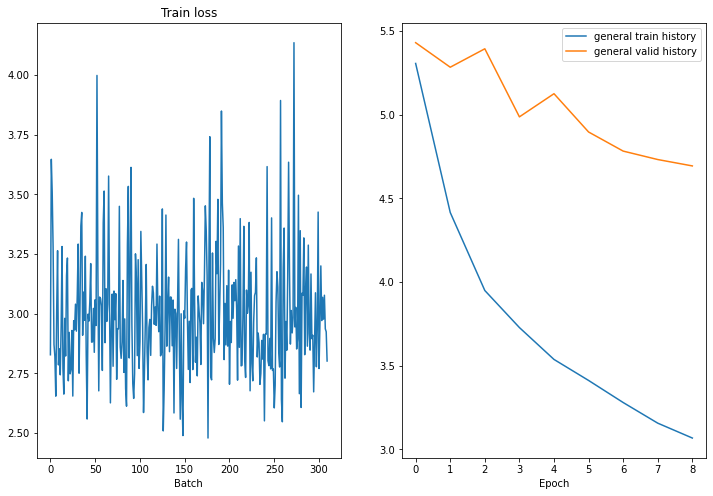

Epoch: 10 | Time: 1m 10s
	Train Loss: 2.998 | Train PPL:  20.040
	 Val. Loss: 4.710 |  Val. PPL: 111.007


In [ ]:
for epoch in range(N_EPOCHS):

    start_time = time.time()

    train_loss = train(model, train_iterator, optimizer, criterion, CLIP, train_history, valid_history)
    valid_loss = evaluate(model, valid_iterator, criterion)

    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'tut1-model.pt')

    train_history.append(train_loss)
    valid_history.append(valid_loss)
    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

__Let's take a look at our network quality__:

In [ ]:
del utils

In [ ]:
import utils
import imp
imp.reload(utils)
generate_translation = utils.generate_translation
remove_tech_tokens = utils.remove_tech_tokens
get_text = utils.get_text
flatten = utils.flatten

In [ ]:
batch = next(iter(test_iterator))

In [ ]:
for idx in [1,2]:
    src = batch.src[:, idx:idx+1]
    trg = batch.trg[:, idx:idx+1]
    generate_translation(src, trg, model, TRG.vocab)

Original: there is a 24 - hour front desk at the property .
Generated: the property offers a 24 - hour front desk . .

Original: this property also features free wifi .
Generated: free wifi access . . . .



In [ ]:
from nltk.translate.bleu_score import corpus_bleu

#     """ Estimates corpora-level BLEU score of model's translations given inp and reference out """
#     translations, _ = model.translate_lines(inp_lines, **flags)
#     # Note: if you experience out-of-memory error, split input lines into batches and translate separately
#     return corpus_bleu([[ref] for ref in out_lines], translations) * 100

In [ ]:
import tqdm

In [ ]:
original_text = []
generated_text = []
model.eval()
with torch.no_grad():

    for i, batch in tqdm.tqdm(enumerate(test_iterator)):

        src = batch.src
        trg = batch.trg

        output = model(src, trg, 0) #turn off teacher forcing

        #trg = [trg sent len, batch size]
        #output = [trg sent len, batch size, output dim]

        output = output.argmax(dim=-1)

        original_text.extend([get_text(x, TRG.vocab) for x in trg.cpu().numpy().T])
        generated_text.extend([get_text(x, TRG.vocab) for x in output[1:].detach().cpu().numpy().T])

# original_text = flatten(original_text)
# generated_text = flatten(generated_text)

59it [00:03, 18.87it/s]


In [ ]:
corpus_bleu([[text] for text in original_text], generated_text) * 100

14.139920232081806